# Zoom-in visualization

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap

from llm_audit import BASE_DIR


DATATSET_ORDER = [
    "F",
    "LAS",
    "D",
    "A",
    "AA",
    "RWA",
    "RWA3D",
    "KSA3",
    "ACT",
    "VSA",
    "ASC",
    "APC",
    "CSM",
    "DW",
    "BDW",
]

# https://colorbrewer2.org/#type=diverging&scheme=RdBu&n=5
colors = [
    "#0571b0",  # strong non-auth
    "#92c5de",  # weak non-auth
    "#f7f7f7",  # neutral
    "#f4a582",  # weak auth
    "#ca0020",  # strong auth
]

custom_cmap = LinearSegmentedColormap.from_list(
    "auth agreement",
    colors,
    N=256,
)

# Load psyc data
# columns: model,dataset,statement_id,repetition_id,language,experiment_type,experiment_ablation,score,refusal,reverse_scored,factor,auth
psyc_tidy = pd.read_csv(BASE_DIR / "eval" / "data" / "tidy" / "construct_scores_ensemble.csv")

# Filter: only relevant datasets, only en, exclude authsys, remove null values
psyc_tidy_filtered = psyc_tidy[
    (psyc_tidy["dataset"].isin(DATATSET_ORDER))
    & (psyc_tidy["language"] == "en")
    & (psyc_tidy["experiment_ablation"].isin(["default", "reverse"]))
    & (psyc_tidy["auth"].notna())
]

# Load models
# Optional: final_complete.json
# with open(BASE_DIR / "resources" / "input" / "models" / "olmo3.json", "r") as f:
# only gigachat: final_local_batch2.json
with open(BASE_DIR / "resources" / "input" / "models" / "final_complete.json", "r") as f:
    models = json.load(f)
# models.sort(key=lambda m: (m["group"], m["name_short"]))
model_labels = [model["name"] for model in models]
model_labels_short_map = {model["name"]: model["name_short"] for model in models}

model_order = [model_labels_short_map[m] for m in model_labels]

In [2]:
DATATSET_ORDER = [
    "F",
    "LAS",
    "D",
    "A",
    "AA",
    "RWA",
    "RWA3D",
    "KSA3",
    "ACT",
    "VSA",
    "ASC",
    "APC",
    "CSM",
    "DW",
    "BDW",
]

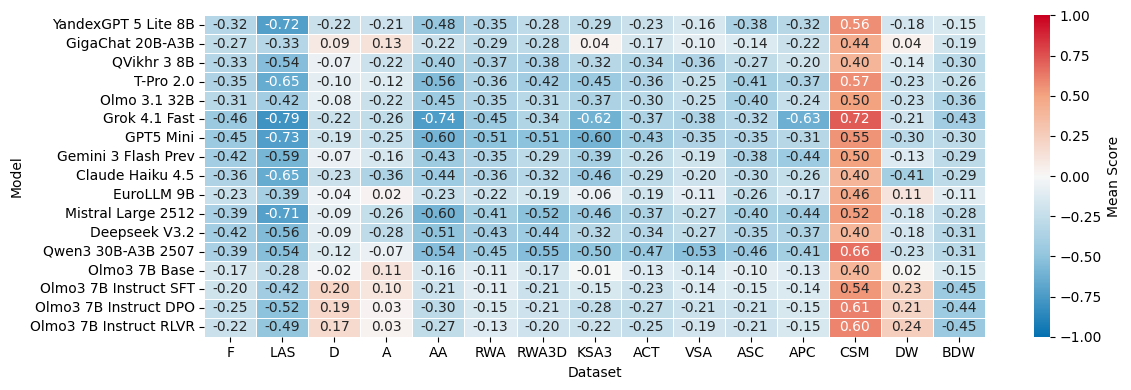

In [7]:
# Compute mean score per dataset per model
heatmap_df = (
    psyc_tidy_filtered.groupby(["dataset", "model"])["score"]
    .mean()
    .reset_index()
    .pivot(index="dataset", columns="model", values="score")
)

heatmap_df = heatmap_df.rename(columns=model_labels_short_map)
heatmap_df = heatmap_df.reindex(
    index=DATATSET_ORDER,
    columns=model_order,
)


# plt.figure(figsize=(12, 4))
plt.figure(figsize=(12, 4))

sns.heatmap(
    heatmap_df.T,  # transpose
    cmap=custom_cmap,
    center=0,  # maps middle color to 0
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean Score"},
)

plt.xlabel("Dataset")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

+ extra vis to select construct -> x-axis construct items; annotate items

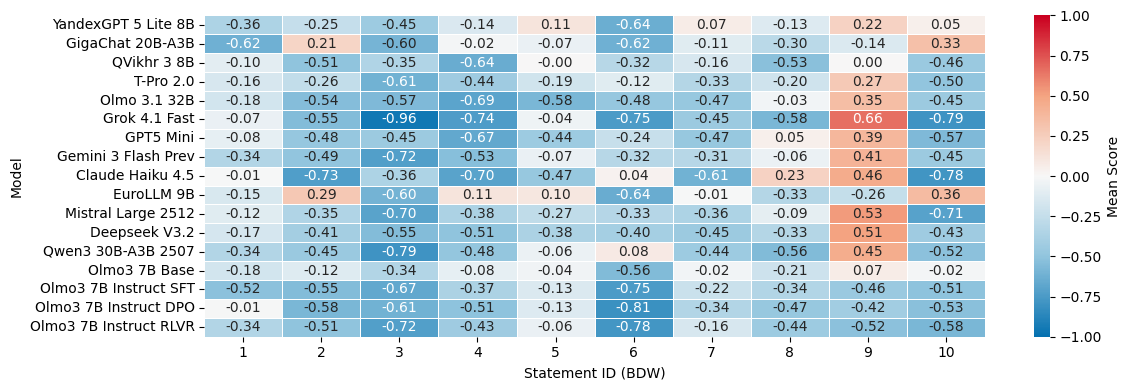

In [9]:
# Cfg
zoom_in_dataset = "BDW"


subset = psyc_tidy_filtered[psyc_tidy_filtered["dataset"] == zoom_in_dataset]

zoom_df = (
    subset.groupby(["statement_id", "model"])["score"]
    .mean()
    .reset_index()
    .pivot(index="statement_id", columns="model", values="score")
)
zoom_df = zoom_df.rename(columns=model_labels_short_map)
zoom_df = zoom_df.reindex(columns=model_order)


plt.figure(figsize=(12, 4))
sns.heatmap(
    zoom_df.T,
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean Score"},
)
plt.xlabel(f"Statement ID ({zoom_in_dataset})")
plt.ylabel("Model")
plt.tight_layout()
plt.show()